In [3]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

from data_loader import DataLoader
from data_processing import DataProcessor
from data_visualization import VisualizerManager


In [4]:
DATASET_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
loader = DataLoader()
df = loader.load_from_url(DATASET_URL, file_type='csv')

if df is not None:
    print(f"Размерность датасета: {df.shape}")
    print(f"Колонки: {list(df.columns)}")
    print("\nПервые 5 строк:")
    display(df.head())
else:
    print("Ошибка загрузки данных")

Данные загружены из URL. Размерность: (891, 12)
Размерность датасета: (891, 12)
Колонки: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Первые 5 строк:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
processor = DataProcessor(df)
missing_abs = processor.count_missing_values()
print("\nПропущенные значения (шт):")
print(missing_abs[missing_abs > 0])
missing_pct = processor.count_missing_values(as_percentage=True)
print("\nПропущенные значения (%):")
print(missing_pct[missing_pct > 0])
cols_with_missing = processor.get_columns_with_missing()
print(f"\nКолонки с пропусками: {cols_with_missing}")


Пропущенные значения (шт):
Cabin       687
Age         177
Embarked      2
dtype: int64

Пропущенные значения (%):
Cabin       77.10
Age         19.87
Embarked     0.22
dtype: float64

Колонки с пропусками: ['Age', 'Cabin', 'Embarked']


In [6]:
report = processor.missing_values_report(detailed=True, sort_by='count')
display(report)


ОТЧЕТ О ПРОПУЩЕННЫХ ЗНАЧЕНИЯХ
Всего строк: 891
Всего колонок: 12
Всего ячеек: 10,692
Всего пропущенных значений: 866
Общий процент пропусков: 8.10%
Колонок с пропусками: 3 из 12
Колонок без пропусков: 9


,Колонка,Тип данных,Всего строк,Не пропущено,Пропущено (шт),Пропущено (%),Уникальных значений,Среднее,Медиана,Станд. откл.,Наиболее частое
10,Cabin,object,891,204,687,77.10,147,NaN,NaN,NaN,B96 B98
5,Age,float64,891,714,177,19.87,88,29.70,28.00,14.53,None
11,Embarked,object,891,889,2,0.22,3,NaN,NaN,NaN,S
0,PassengerId,int64,891,891,0,0.00,891,446.00,446.00,257.35,None
3,Name,object,891,891,0,0.00,891,NaN,NaN,NaN,"Abbing, Mr. Anthony"
2,Pclass,int64,891,891,0,0.00,3,2.31,3.00,0.84,None
1,Survived,int64,891,891,0,0.00,2,0.38,0.00,0.49,None
4,Sex,object,891,891,0,0.00,2,NaN,NaN,NaN,male
7,Parch,int64,891,891,0,0.00,7,0.38,0.00,0.81,None
6,SibSp,int64,891,891,0,0.00,7,0.52,0.00,1.10,None


In [8]:
df_clean = df.copy()
processor_clean = DataProcessor(df_clean)

# Age медианой
processor_clean.fill_missing_values(strategy='median', columns=['Age'], inplace=True)

# Embarked модой
processor_clean.fill_missing_values(strategy='mode', columns=['Embarked'], inplace=True)

# Cabin константой 'Unknown'
processor_clean.fill_missing_values(strategy='constant', columns=['Cabin'], fill_value='Unknown', inplace=True)

print(f"Осталось пропусков: {df_clean.isnull().sum().sum()}")


ЗАПОЛНЕНИЕ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ЗАВЕРШЕНО
   Стратегия: median
   Обработано колонок: 1
   Заполнено пропусков: 177
   Осталось пропусков: 689
   Заполнено 20.4% от всех пропусков

ЗАПОЛНЕНИЕ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ЗАВЕРШЕНО
   Стратегия: mode
   Обработано колонок: 1
   Заполнено пропусков: 2
   Осталось пропусков: 687
   Заполнено 0.3% от всех пропусков

ЗАПОЛНЕНИЕ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ЗАВЕРШЕНО
   Стратегия: constant
   Обработано колонок: 1
   Заполнено пропусков: 687
   Осталось пропусков: 0
   Заполнено 100.0% от всех пропусков
Осталось пропусков: 0



--- График ID: 1, Тип: histogram ---


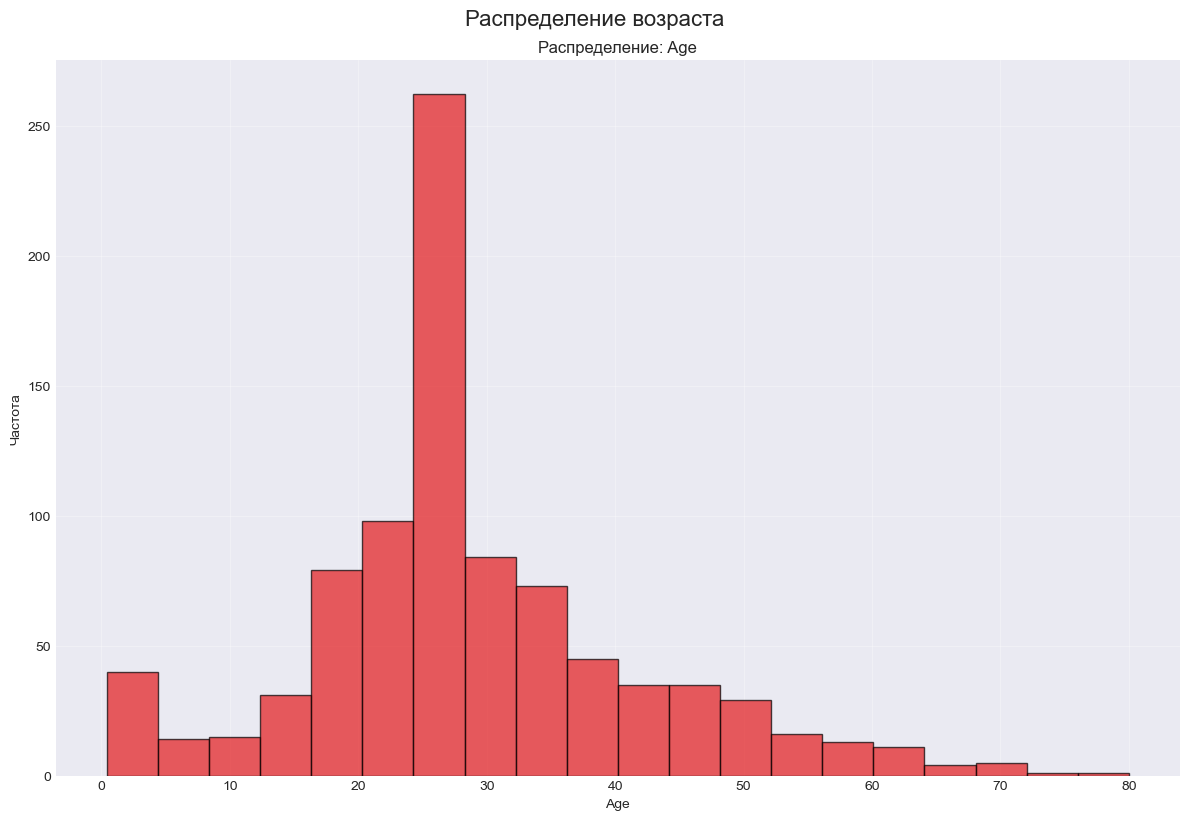


--- График ID: 2, Тип: boxplot ---


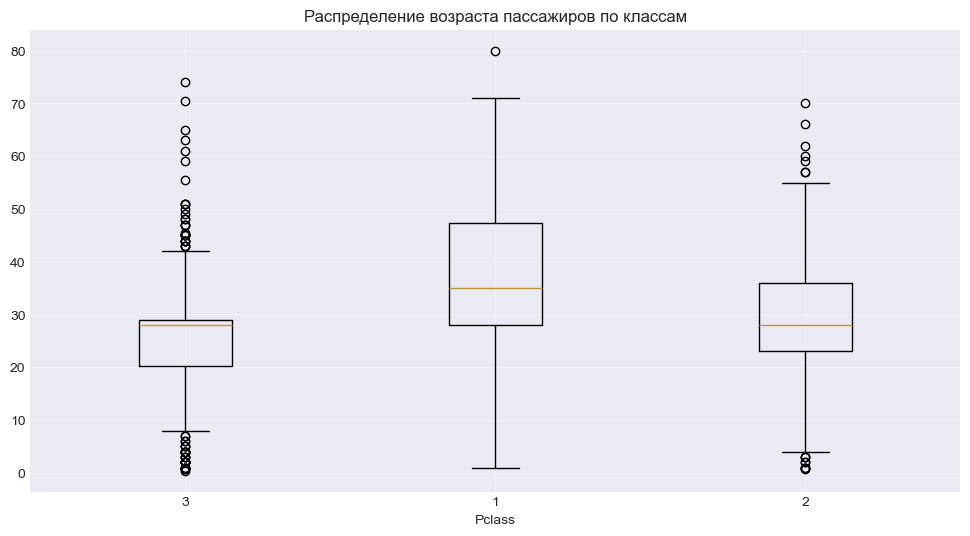


--- График ID: 3, Тип: histogram ---


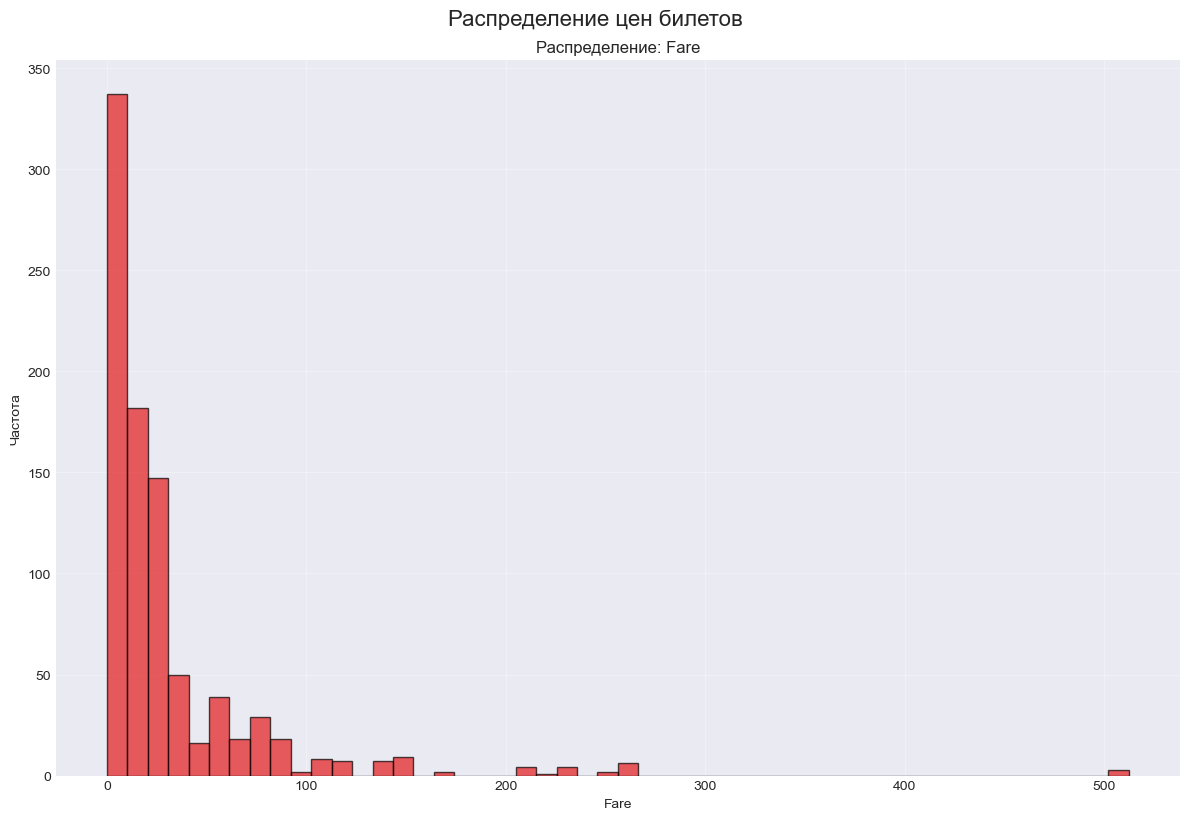


--- График ID: 4, Тип: heatmap ---


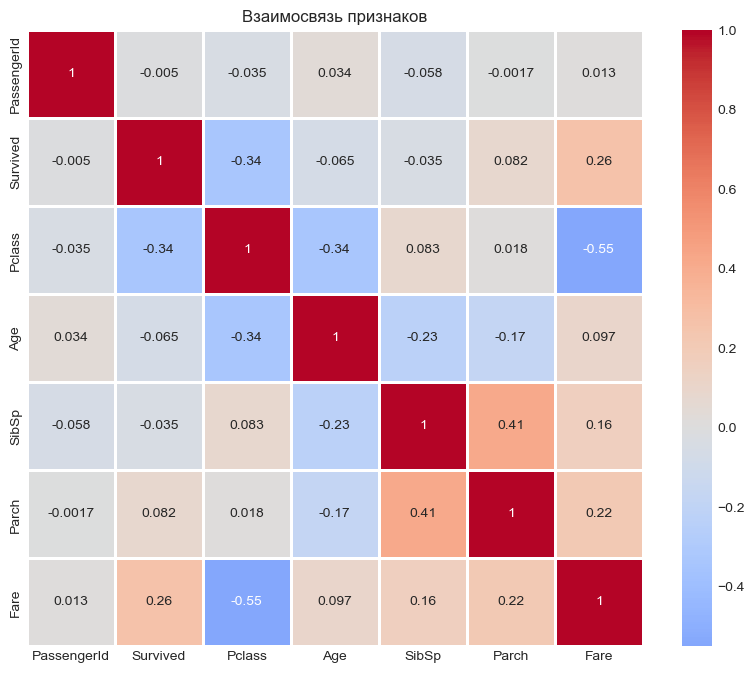


--- График ID: 5, Тип: boxplot ---


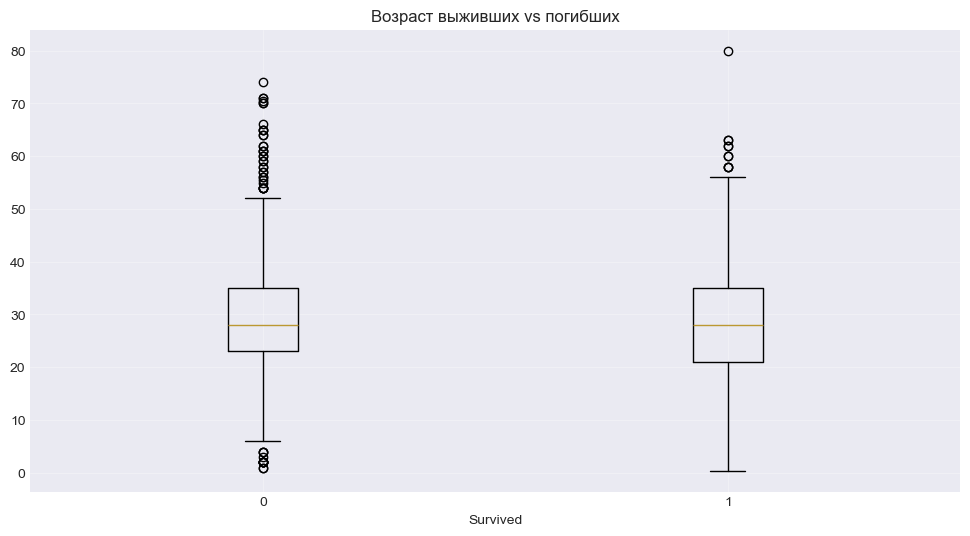

In [24]:
visualizer = VisualizerManager(df_clean)

id1 = visualizer.add_histogram(columns=['Age'], bins=20, title="Распределение возраста")

id2 = visualizer.add_boxplot(columns=['Age'], by='Pclass',title="Распределение возраста пассажиров по классам")

id3=visualizer.add_histogram(columns=['Fare'], bins=50,title="Распределение цен билетов")

id4=visualizer.add_heatmap(title="Взаимосвязь признаков")

id5=visualizer.add_boxplot(columns=['Age'], by='Survived', title="Возраст выживших vs погибших")

visualizer.show_plot()